In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yasserh/twitter-tweets-sentiment-dataset/Tweets.csv


# Step 1: Dataset Exploration

Shape: (27481, 4)

Column Names: ['textID', 'text', 'selected_text', 'sentiment']

Data Types:
 textID           object
text             object
selected_text    object
sentiment        object
dtype: object

First 5 Rows:
        textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  

Missing Values:
 textID           0
text             1
selecte

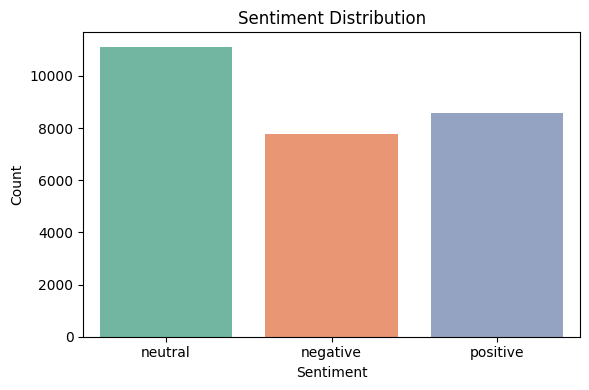


Tweet Length Stats:
 count    27481.000000
mean        68.327645
std         35.605403
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: tweet_length, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/yasserh/twitter-tweets-sentiment-dataset/Tweets.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())

# Check for nulls
print("\nMissing Values:\n", df.isnull().sum())

# Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Sentiment distribution
print("\nSentiment Value Counts:\n", df['sentiment'].value_counts())

# Plot sentiment distribution — hue fix applied
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', hue='sentiment', data=df, palette='Set2', legend=False)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Sample tweet lengths
df['tweet_length'] = df['text'].astype(str).apply(len)
print("\nTweet Length Stats:\n", df['tweet_length'].describe())

# Step 2: Data Preprocessing

In [3]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Drop nulls and irrelevant columns
df = df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)
df = df[['text', 'sentiment']].copy()
print(f"Shape after dropping nulls: {df.shape}")

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep sentiment-bearing stopwords — these matter for sentiment!
keep_words = {'not', 'no', 'nor', 'but', 'very', 'too', 'against', "don't", "isn't", "wasn't", "couldn't", "wouldn't"}
stop_words = stop_words - keep_words

def clean_text(text):
    text = str(text).lower()                             # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)          # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)                # Strip # but keep hashtag word
    text = re.sub(r'[^a-z\s]', '', text)                 # Remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()             # Remove extra spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

# Label encoding
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

# Check results
print("\nSample cleaned tweets:")
print(df[['text', 'cleaned_text', 'sentiment', 'label']].head(8).to_string())

# Check for any empty strings after cleaning
empty = df['cleaned_text'].str.strip().eq('').sum()
print(f"\nEmpty strings after cleaning: {empty}")

print("\nLabel Distribution:\n", df['label'].value_counts())

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


Shape after dropping nulls: (27480, 2)

Sample cleaned tweets:
                                                                                           text                                cleaned_text sentiment  label
0                                                           I`d have responded, if I were going                          id responded going   neutral      1
1                                                 Sooo SAD I will miss you here in San Diego!!!                     sooo sad miss san diego  negative      0
2                                                                     my boss is bullying me...                                bos bullying  negative      0
3                                                                what interview! leave me alone                       interview leave alone  negative      0
4                    Sons of ****, why couldn`t they put them on the releases we already bought      son couldnt put release already bought  negative   

# Step 3: Split the Dataset

In [4]:
from sklearn.model_selection import train_test_split

# Drop empty strings that resulted from cleaning
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f"Shape after dropping empty cleaned texts: {df.shape}")

X = df['cleaned_text'].values
y = df['label'].values

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 50% of temp → 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain size : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val size   : {len(X_val)}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size  : {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")

# Verify class balance is preserved across splits
import pandas as pd
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = pd.Series(y_split).value_counts().sort_index()
    print(f"\n{name} label distribution:")
    for label, count in counts.items():
        print(f"  {label_names[label]}: {count} ({count/len(y_split)*100:.1f}%)")

Shape after dropping empty cleaned texts: (27424, 4)

Train size : 21939 (80.0%)
Val size   : 2742  (10.0%)
Test size  : 2743  (10.0%)

Train label distribution:
  negative: 6222 (28.4%)
  neutral: 8853 (40.4%)
  positive: 6864 (31.3%)

Val label distribution:
  negative: 778 (28.4%)
  neutral: 1106 (40.3%)
  positive: 858 (31.3%)

Test label distribution:
  negative: 778 (28.4%)
  neutral: 1107 (40.4%)
  positive: 858 (31.3%)


# Step 4: TF-IDF Feature Extraction

In [7]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

# ── Merge train + val back (SVM/XGBoost use CV, not a val set) ──────
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
print(f"Train+Val size : {len(X_trainval)}")
print(f"Test size      : {len(X_test)}")

# ── TF-IDF Hyperparameters ───────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features   = 30000,      # Top 30k features
    ngram_range    = (1, 3),     # Unigrams + Bigrams + Trigrams
    sublinear_tf   = True,       # Log normalization — reduces dominance of frequent words
    min_df         = 2,          # Ignore terms appearing in fewer than 2 docs
    max_df         = 0.95,       # Ignore terms appearing in >95% of docs (too common)
    analyzer       = 'word',
    strip_accents  = 'unicode',
    token_pattern  = r'\w{1,}',  # Capture all words including short ones
)

# ── Fit ONLY on train+val — never on test ────────────────────────────
X_trainval_tfidf = tfidf.fit_transform(X_trainval)
X_test_tfidf     = tfidf.transform(X_test)

print(f"\nTF-IDF matrix shape (train+val) : {X_trainval_tfidf.shape}")
print(f"TF-IDF matrix shape (test)      : {X_test_tfidf.shape}")
print(f"Matrix is sparse                : {type(X_trainval_tfidf)}")

# ── Top features sanity check ────────────────────────────────────────
feature_names = tfidf.get_feature_names_out()
print(f"\nTotal features extracted: {len(feature_names)}")
print(f"Sample features (first 20): {feature_names[:20].tolist()}")
print(f"Sample features (last 20) : {feature_names[-20:].tolist()}")

# ── Save TF-IDF vectorizer for inference ─────────────────────────────
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("\nTF-IDF vectorizer saved to tfidf_vectorizer.pkl")

Train+Val size : 24681
Test size      : 2743

TF-IDF matrix shape (train+val) : (24681, 24327)
TF-IDF matrix shape (test)      : (2743, 24327)
Matrix is sparse                : <class 'scipy.sparse._csr.csr_matrix'>

Total features extracted: 24327
Sample features (first 20): ['aaaah', 'aaah', 'aaahhh', 'aaawww', 'aah', 'aah well', 'aargh', 'aaron', 'ab', 'abandoned', 'abandoning', 'abbey', 'abby', 'abc', 'abiding', 'ability', 'abit', 'abit better', 'able', 'able breath']
Sample features (last 20) : ['z', 'z no', 'z no high', 'zac', 'zac efron', 'zach', 'zachary', 'zachary quinto', 'zack', 'ze', 'zealand', 'zero', 'zoe', 'zombie', 'zone', 'zoo', 'zu', 'zulu', 'zune', 'zzzz']

TF-IDF vectorizer saved to tfidf_vectorizer.pkl


# Step 5: Train SVM + XGBoost

In [8]:
import numpy as np
import time
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import pickle

# ── Class Weights ────────────────────────────────────────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_trainval),
    y=y_trainval
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class Weights:", {k: round(v, 4) for k, v in class_weight_dict.items()})

# ── Cross Validation Setup ───────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ════════════════════════════════════════════════════════════════════
# MODEL 1: LinearSVC (best SVM variant for high-dim sparse TF-IDF)
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("Training Model 1: LinearSVC")
print("="*55)

svm = LinearSVC(
    C              = 0.8,        # Slight regularization
    max_iter       = 2000,
    class_weight   = 'balanced',
    random_state   = 42
)

# Wrap with CalibratedClassifierCV to get probability scores
svm_calibrated = CalibratedClassifierCV(svm, cv=3)

t0 = time.time()
cv_scores_svm = cross_val_score(
    svm_calibrated, X_trainval_tfidf, y_trainval,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)
print(f"\nSVM 5-Fold CV Accuracy : {cv_scores_svm}")
print(f"SVM Mean CV Accuracy   : {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}")
print(f"Time taken             : {time.time()-t0:.1f}s")

# Final fit on full train+val
svm_calibrated.fit(X_trainval_tfidf, y_trainval)
print("SVM final model trained ✓")

# ════════════════════════════════════════════════════════════════════
# MODEL 2: XGBoost
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("Training Model 2: XGBoost")
print("="*55)

# Compute sample weights for XGBoost
sample_weights = np.array([class_weights_array[y] for y in y_trainval])

xgb = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = 'hist'   # Fastest for large sparse matrices
)

t0 = time.time()
cv_scores_xgb = cross_val_score(
    xgb, X_trainval_tfidf, y_trainval,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=1
)
print(f"\nXGB 5-Fold CV Accuracy : {cv_scores_xgb}")
print(f"XGB Mean CV Accuracy   : {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")
print(f"Time taken             : {time.time()-t0:.1f}s")

# Final fit on full train+val
xgb.fit(X_trainval_tfidf, y_trainval, sample_weight=sample_weights)
print("XGB final model trained ✓")

# ════════════════════════════════════════════════════════════════════
# MODEL COMPARISON SUMMARY
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("MODEL COMPARISON (5-Fold CV on Train+Val)")
print("="*55)
print(f"{'Model':<20} {'Mean Acc':>10} {'Std':>8}")
print("-"*40)
print(f"{'LinearSVC':<20} {cv_scores_svm.mean():>10.4f} {cv_scores_svm.std():>8.4f}")
print(f"{'XGBoost':<20} {cv_scores_xgb.mean():>10.4f} {cv_scores_xgb.std():>8.4f}")

# Pick best model
if cv_scores_svm.mean() >= cv_scores_xgb.mean():
    best_model = svm_calibrated
    best_name  = "LinearSVC"
else:
    best_model = xgb
    best_name  = "XGBoost"

print(f"\n✅ Best Model Selected: {best_name}")

# Save both models
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_calibrated, f)
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("All models saved ✓")

Class Weights: {0: np.float64(1.1753), 1: np.float64(0.8261), 2: np.float64(1.0654)}

Training Model 1: LinearSVC


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.2s finished



SVM 5-Fold CV Accuracy : [0.68361353 0.69286872 0.69469206 0.69003241 0.69266613]
SVM Mean CV Accuracy   : 0.6908 ± 0.0039
Time taken             : 3.3s
SVM final model trained ✓

Training Model 2: XGBoost


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:40:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:40:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:40:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:40:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.1


XGB 5-Fold CV Accuracy : [0.69029775 0.69104538 0.69550243 0.69732577 0.69712318]
XGB Mean CV Accuracy   : 0.6943 ± 0.0030
Time taken             : 271.4s
XGB final model trained ✓

MODEL COMPARISON (5-Fold CV on Train+Val)
Model                  Mean Acc      Std
----------------------------------------
LinearSVC                0.6908   0.0039
XGBoost                  0.6943   0.0030

✅ Best Model Selected: XGBoost
All models saved ✓


  Test Accuracy  —  SVM: 0.6945  |  XGB: 0.7105

── LinearSVC Classification Report ──
              precision    recall  f1-score   support

    negative       0.72      0.61      0.66       778
     neutral       0.63      0.71      0.67      1107
    positive       0.76      0.75      0.75       858

    accuracy                           0.69      2743
   macro avg       0.71      0.69      0.70      2743
weighted avg       0.70      0.69      0.69      2743


── XGBoost Classification Report ──
              precision    recall  f1-score   support

    negative       0.74      0.63      0.68       778
     neutral       0.65      0.75      0.69      1107
    positive       0.79      0.73      0.76       858

    accuracy                           0.71      2743
   macro avg       0.72      0.70      0.71      2743
weighted avg       0.72      0.71      0.71      2743



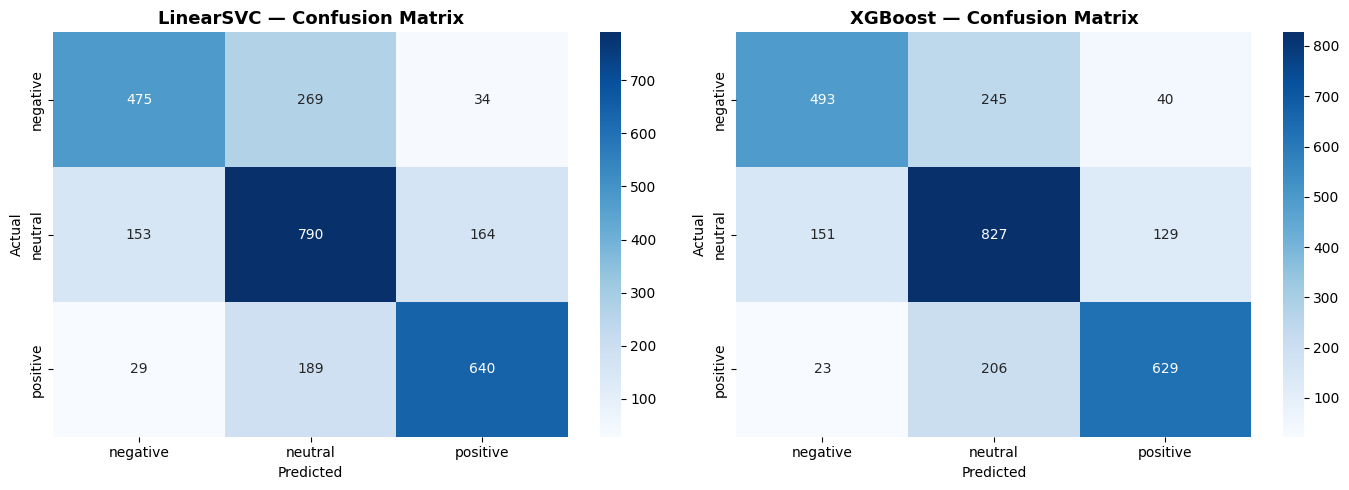


Weighted ROC-AUC  —  SVM: 0.8405  |  XGB: 0.8492


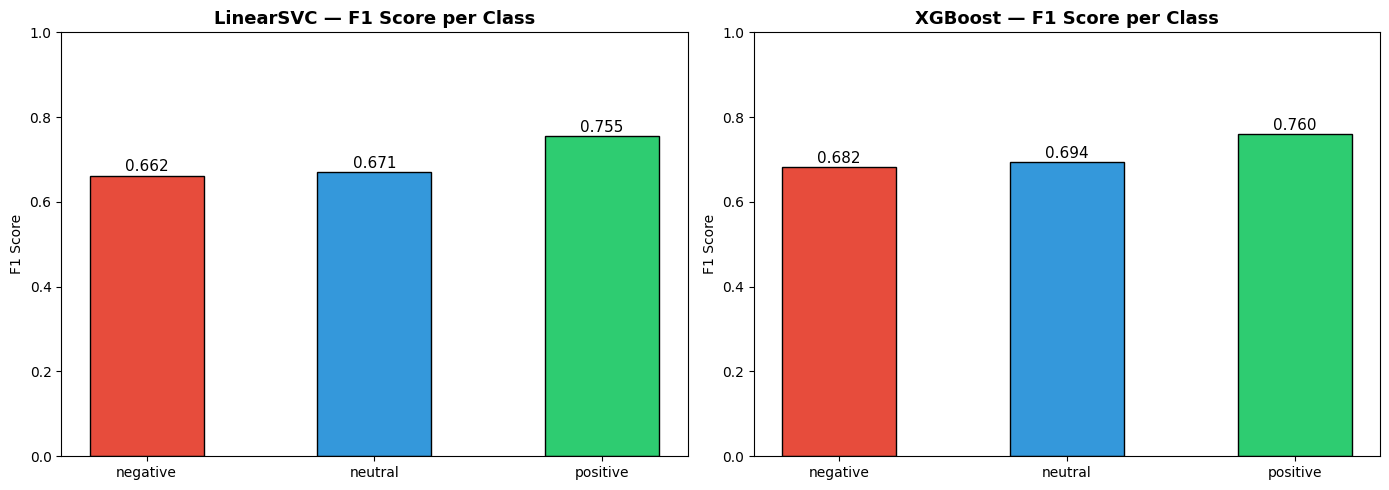


FINAL MODEL SUMMARY
          Metric LinearSVC XGBoost
   Test Accuracy    0.6945  0.7105
Weighted ROC-AUC    0.8405  0.8492
CV Mean Accuracy    0.6908  0.6943

CUSTOM TWEET PREDICTIONS (Best Model: XGBoost)

Tweet                                          Predicted   Confidence
----------------------------------------------------------------------
I absolutely love this!                         positive       85.7%
This is the worst experience ever               negative       64.1%
The movie was just okay, nothing special         neutral       47.0%
Amazing performance by the team today!!         positive       72.2%
I'm really disappointed with the service        negative       51.9%
Not bad, could be better though                 negative       44.1%
so happy right now!!!                           positive       86.0%
ugh this is so frustrating                      negative       69.0%


In [9]:
# Step 6: Model Evaluation

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             roc_auc_score)
import pandas as pd

label_names  = ['negative', 'neutral', 'positive']
label_map_inv = {0: 'negative', 1: 'neutral', 2: 'positive'}

# ── Predictions ──────────────────────────────────────────────────────
svm_preds  = svm_calibrated.predict(X_test_tfidf)
xgb_preds  = xgb.predict(X_test_tfidf)

svm_probs  = svm_calibrated.predict_proba(X_test_tfidf)
xgb_probs  = xgb.predict_proba(X_test_tfidf)

# ── Accuracy ─────────────────────────────────────────────────────────
svm_acc = accuracy_score(y_test, svm_preds)
xgb_acc = accuracy_score(y_test, xgb_preds)

print("="*55)
print(f"  Test Accuracy  —  SVM: {svm_acc:.4f}  |  XGB: {xgb_acc:.4f}")
print("="*55)

# ── Classification Reports ───────────────────────────────────────────
print("\n── LinearSVC Classification Report ──")
print(classification_report(y_test, svm_preds, target_names=label_names))

print("\n── XGBoost Classification Report ──")
print(classification_report(y_test, xgb_preds, target_names=label_names))

# ── Confusion Matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [svm_preds, xgb_preds],
    ['LinearSVC', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names, ax=ax)
    ax.set_title(f'{title} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ── ROC-AUC (One vs Rest) ────────────────────────────────────────────
svm_auc = roc_auc_score(y_test, svm_probs, multi_class='ovr', average='weighted')
xgb_auc = roc_auc_score(y_test, xgb_probs, multi_class='ovr', average='weighted')
print(f"\nWeighted ROC-AUC  —  SVM: {svm_auc:.4f}  |  XGB: {xgb_auc:.4f}")

# ── Per-Class Accuracy Bar Chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [svm_preds, xgb_preds],
    ['LinearSVC', 'XGBoost']
):
    report = classification_report(y_test, preds,
                                   target_names=label_names,
                                   output_dict=True)
    f1_scores = [report[l]['f1-score'] for l in label_names]
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    bars = ax.bar(label_names, f1_scores, color=colors, edgecolor='black', width=0.5)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} — F1 Score per Class', fontsize=13, fontweight='bold')
    ax.set_ylabel('F1 Score')
    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# ── Final Summary Table ───────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL MODEL SUMMARY")
print("="*55)
summary = pd.DataFrame({
    'Metric'   : ['Test Accuracy', 'Weighted ROC-AUC', 'CV Mean Accuracy'],
    'LinearSVC': [f"{svm_acc:.4f}", f"{svm_auc:.4f}", f"{cv_scores_svm.mean():.4f}"],
    'XGBoost'  : [f"{xgb_acc:.4f}", f"{xgb_auc:.4f}", f"{cv_scores_xgb.mean():.4f}"]
})
print(summary.to_string(index=False))

# ── Custom Tweet Predictions (like the bronze script) ─────────────────
print("\n" + "="*55)
print("CUSTOM TWEET PREDICTIONS (Best Model: XGBoost)")
print("="*55)

custom_tweets_raw = [
    "I absolutely love this!",
    "This is the worst experience ever",
    "The movie was just okay, nothing special",
    "Amazing performance by the team today!!",
    "I'm really disappointed with the service",
    "Not bad, could be better though",
    "so happy right now!!!",
    "ugh this is so frustrating"
]

# Clean using same function from Step 2
custom_cleaned = [clean_text(t) for t in custom_tweets_raw]
custom_tfidf   = tfidf.transform(custom_cleaned)
custom_preds   = xgb.predict(custom_tfidf)
custom_probs   = xgb.predict_proba(custom_tfidf)

print(f"\n{'Tweet':<45} {'Predicted':>10} {'Confidence':>12}")
print("-"*70)
for tweet, pred, prob in zip(custom_tweets_raw, custom_preds, custom_probs):
    confidence = prob.max() * 100
    sentiment  = label_map_inv[pred]
    print(f"{tweet:<45} {sentiment:>10} {confidence:>10.1f}%")